In [1]:
import sys
import os
sys.path.append(os.path.abspath("../"))

In [2]:
from utils.loaders import load_sweep
from utils.styles import apply
from utils.analysis import cbs_profiles, linear, circular, keep, phi_cut, azimuthal_average

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

apply(context="paper", col="single")

In [3]:
save_path = "/Users/niaggar/Results"

radius_values = [0.020, 0.035, 0.055, 0.075, 0.100, 0.175]
N_REPLICAS = 5

data_names = []
for rep in range(N_REPLICAS):
    for index, rad in enumerate(radius_values):
        name = f"radius_{rad:.3f}__rep{rep}"
        val = index * N_REPLICAS + rep
        full_name = f"{val:04d}_{name}"
        data_names.append((full_name, rf"R={rad*1000:.0f} $\mu$m"))

print(data_names)

[('0000_radius_0.020__rep0', 'R=20 $\\mu$m'), ('0005_radius_0.035__rep0', 'R=35 $\\mu$m'), ('0010_radius_0.055__rep0', 'R=55 $\\mu$m'), ('0015_radius_0.075__rep0', 'R=75 $\\mu$m'), ('0020_radius_0.100__rep0', 'R=100 $\\mu$m'), ('0025_radius_0.175__rep0', 'R=175 $\\mu$m'), ('0001_radius_0.020__rep1', 'R=20 $\\mu$m'), ('0006_radius_0.035__rep1', 'R=35 $\\mu$m'), ('0011_radius_0.055__rep1', 'R=55 $\\mu$m'), ('0016_radius_0.075__rep1', 'R=75 $\\mu$m'), ('0021_radius_0.100__rep1', 'R=100 $\\mu$m'), ('0026_radius_0.175__rep1', 'R=175 $\\mu$m'), ('0002_radius_0.020__rep2', 'R=20 $\\mu$m'), ('0007_radius_0.035__rep2', 'R=35 $\\mu$m'), ('0012_radius_0.055__rep2', 'R=55 $\\mu$m'), ('0017_radius_0.075__rep2', 'R=75 $\\mu$m'), ('0022_radius_0.100__rep2', 'R=100 $\\mu$m'), ('0027_radius_0.175__rep2', 'R=175 $\\mu$m'), ('0003_radius_0.020__rep3', 'R=20 $\\mu$m'), ('0008_radius_0.035__rep3', 'R=35 $\\mu$m'), ('0013_radius_0.055__rep3', 'R=55 $\\mu$m'), ('0018_radius_0.075__rep3', 'R=75 $\\mu$m'), ('0

# Linear Polarization study of RGD particles

In [4]:
folder_lineal = "study_rgd_particles__PLIN__beam2500"
sweep_data_lineal = load_sweep(folder_lineal, base_path=Path(save_path))

data_keys = list(sweep_data_lineal.keys())
print(f"Loaded {len(data_keys)} datasets: {data_keys}")


Loaded 30 datasets: ['0012_radius_0.055__rep2', '0021_radius_0.100__rep1', '0001_radius_0.020__rep1', '0016_radius_0.075__rep1', '0025_radius_0.175__rep0', '0007_radius_0.035__rep2', '0009_radius_0.035__rep4', '0015_radius_0.075__rep0', '0026_radius_0.175__rep1', '0023_radius_0.100__rep3', '0010_radius_0.055__rep0', '0005_radius_0.035__rep0', '0027_radius_0.175__rep2', '0019_radius_0.075__rep4', '0003_radius_0.020__rep3', '0014_radius_0.055__rep4', '0029_radius_0.175__rep4', '0017_radius_0.075__rep2', '0006_radius_0.035__rep1', '0028_radius_0.175__rep3', '0002_radius_0.020__rep2', '0011_radius_0.055__rep1', '0022_radius_0.100__rep2', '0018_radius_0.075__rep3', '0004_radius_0.020__rep4', '0024_radius_0.100__rep4', '0008_radius_0.035__rep3', '0000_radius_0.020__rep0', '0020_radius_0.100__rep0', '0013_radius_0.055__rep3']


In [5]:
def load_stitched(sweep, key, basis, reduce, channel, k, lstar):
    """Une det_1 (fino) y det_2 (cola) promediando la banda de solape.
    Devuelve theta [rad], q=k*lstar*theta, y el enhancement del canal."""
    p1 = cbs_profiles(sweep[key].processed_cbs("farfield_cbs_1"),
                      basis=basis, time_index=0, reduce=reduce)
    p2 = cbs_profiles(sweep[key].processed_cbs("farfield_cbs_2"),
                      basis=basis, time_index=0, reduce=reduce)
    th1, g1 = np.asarray(p1.theta), np.asarray(p1.enhancement[channel])
    th2, g2 = np.asarray(p2.theta), np.asarray(p2.enhancement[channel])

    theta_1 = th1[-1]                       # fin de la ventana fina
    lo = 0.9 * theta_1                       # inicio real de det_2 (solape)

    # --- chequeo de stitching: interpola det_1 sobre los bins de solape de det_2
    ov = (th2 >= lo) & (th2 <= theta_1)
    if ov.any():
        g1_on2 = np.interp(th2[ov], th1, g1)
        resid = np.abs(g2[ov] - g1_on2)
        if np.max(resid) > 0.05:            # umbral: 5% del enhancement
            print(f"[stitch WARN] {key} ch={channel}: max solape "
                  f"{np.max(resid):.3f} -- revisar normalizacion angulo solido")

    # une: det_1 completo + det_2 estrictamente por encima de theta_1
    keep2 = th2 > theta_1
    theta = np.concatenate([th1, th2[keep2]])
    g = np.concatenate([g1, g2[keep2]])
    q = k * lstar * theta
    return theta, q, g

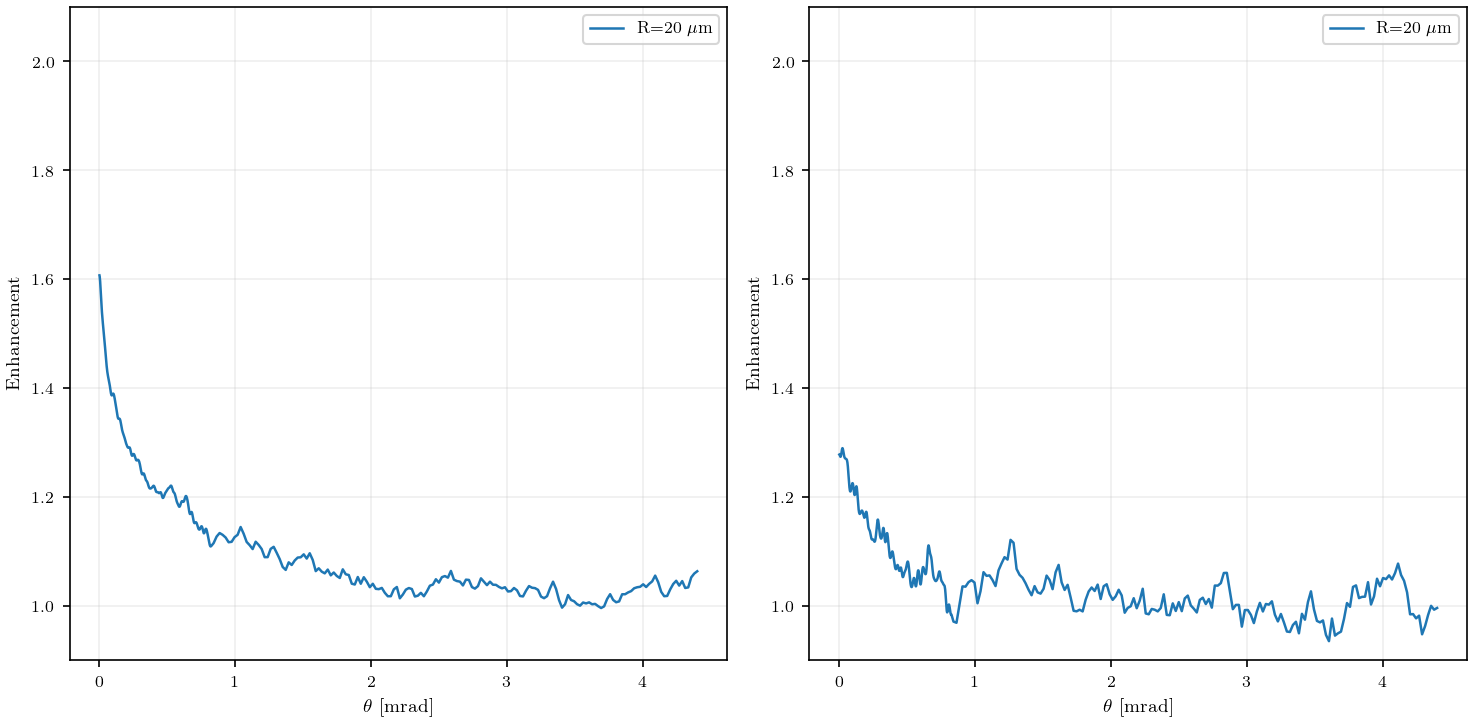

In [6]:
fig, (axes1, axes2) = plt.subplots(1, 2, figsize=(10, 5))

i = 0
for ch, title in data:
    if i == 1:
        continue
    prof = cbs_profiles(
        sweep_data_lineal[ch].processed_cbs("farfield_cbs_1"),
        basis=linear, time_index=0, reduce=phi_cut(0),
    )
    prof_2 = cbs_profiles(
        sweep_data_lineal[ch].processed_cbs("farfield_cbs_2"),
        basis=linear, time_index=0, reduce=phi_cut(0),
    )
    th = prof.theta * 1e3
    th_2 = prof_2.theta * 1e3

    idx = np.searchsorted(th_2, th[-1], side='right')
    th_2 = th_2[idx:]


    Ico = prof.enhancement["co"]
    Icross = prof.enhancement["cross"]

    Ico_2 = prof_2.enhancement["co"]
    Icross_2 = prof_2.enhancement["cross"]

    Ico_2 = Ico_2[idx:]
    Icross_2 = Icross_2[idx:]

    # Concatenate the two profiles
    th = np.concatenate((th, th_2))
    Ico = np.concatenate((Ico, Ico_2))
    Icross = np.concatenate((Icross, Icross_2))

    axes1.plot(th, Ico, label=title)
    axes2.plot(th, Icross, label=title)

    i = 1
    

axes1.set_xlabel(r"$\theta$ [mrad]")
axes1.set_ylabel(r"Enhancement")
axes1.set_ylim(0.9, 2.1)
axes1.grid(alpha=0.2)
axes1.legend(loc="upper right", fontsize=8)
axes2.set_xlabel(r"$\theta$ [mrad]")
axes2.set_ylabel(r"Enhancement")
axes2.set_ylim(0.9, 2.1)
axes2.grid(alpha=0.2)
axes2.legend(loc="upper right", fontsize=8)
fig.tight_layout()
# fig.savefig(out, dpi=200)
plt.show()
    

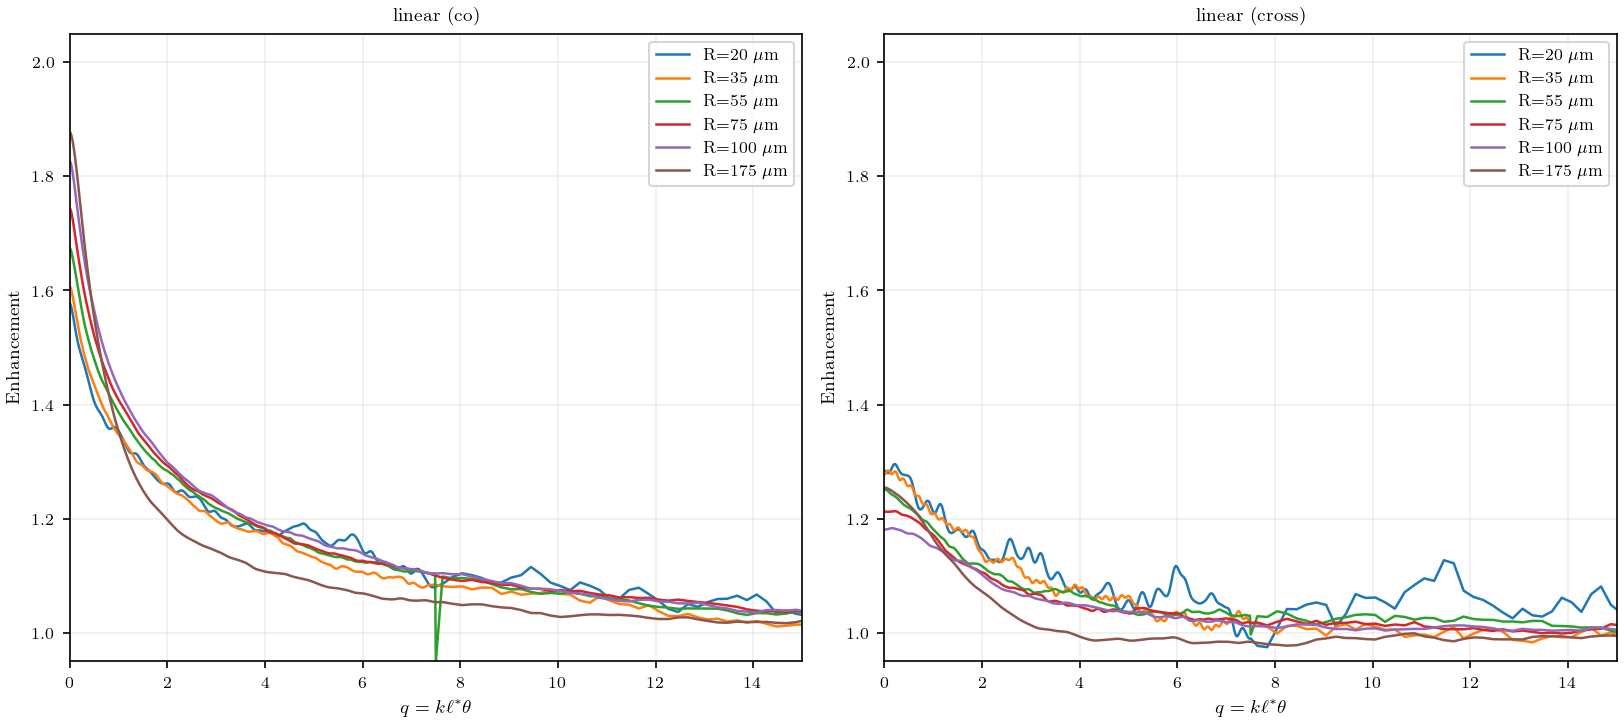

In [7]:
N_MEDIUM = 1.33
WAVELENGTH = 0.514
k = 2 * np.pi * N_MEDIUM / WAVELENGTH


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

for (key, title), rad in zip(data, radius_values):
    lstar = sweep_data_lineal[key].params_flat["transport_mean_free_path"]
    red = phi_cut(0)
    
    for ax, chan in [(ax1, "co"), (ax2, "cross")]:
        theta, q, g = load_stitched(sweep_data_lineal, key, linear, red, chan, k, lstar)
        base = np.median(g[q > 25])          # fondo medido en la cola (q grande)
        ax.plot(q, g - base + 1.0, label=title)   # baseline normalizada a 1

for ax, t in [(ax1, "co"), (ax2, "cross")]:
    ax.set_xlabel(r"$q = k\ell^*\theta$"); ax.set_ylabel("Enhancement")
    ax.set_xlim(0, 15); ax.set_ylim(0.95, 2.05); ax.grid(alpha=0.2)
    ax.legend(fontsize=8); ax.set_title(f"linear ({t})")
fig.tight_layout(); plt.show()

claves: ['0012_radius_0.055__rep2', '0021_radius_0.100__rep1', '0001_radius_0.020__rep1', '0016_radius_0.075__rep1', '0025_radius_0.175__rep0', '0007_radius_0.035__rep2', '0009_radius_0.035__rep4', '0015_radius_0.075__rep0', '0026_radius_0.175__rep1', '0023_radius_0.100__rep3', '0010_radius_0.055__rep0', '0005_radius_0.035__rep0', '0027_radius_0.175__rep2', '0019_radius_0.075__rep4', '0003_radius_0.020__rep3', '0014_radius_0.055__rep4', '0029_radius_0.175__rep4', '0017_radius_0.075__rep2', '0006_radius_0.035__rep1', '0028_radius_0.175__rep3', '0002_radius_0.020__rep2', '0011_radius_0.055__rep1', '0022_radius_0.100__rep2', '0018_radius_0.075__rep3', '0004_radius_0.020__rep4', '0024_radius_0.100__rep4', '0008_radius_0.035__rep3', '0000_radius_0.020__rep0', '0020_radius_0.100__rep0', '0013_radius_0.055__rep3']

        r[um]         l*[um]          E0_co         rho_co  FWHM_co[mrad]      q_FWHM_co       E0_cross  FWHM_cr[mrad]        base_co
       0.0200       558.9582         1.5802   

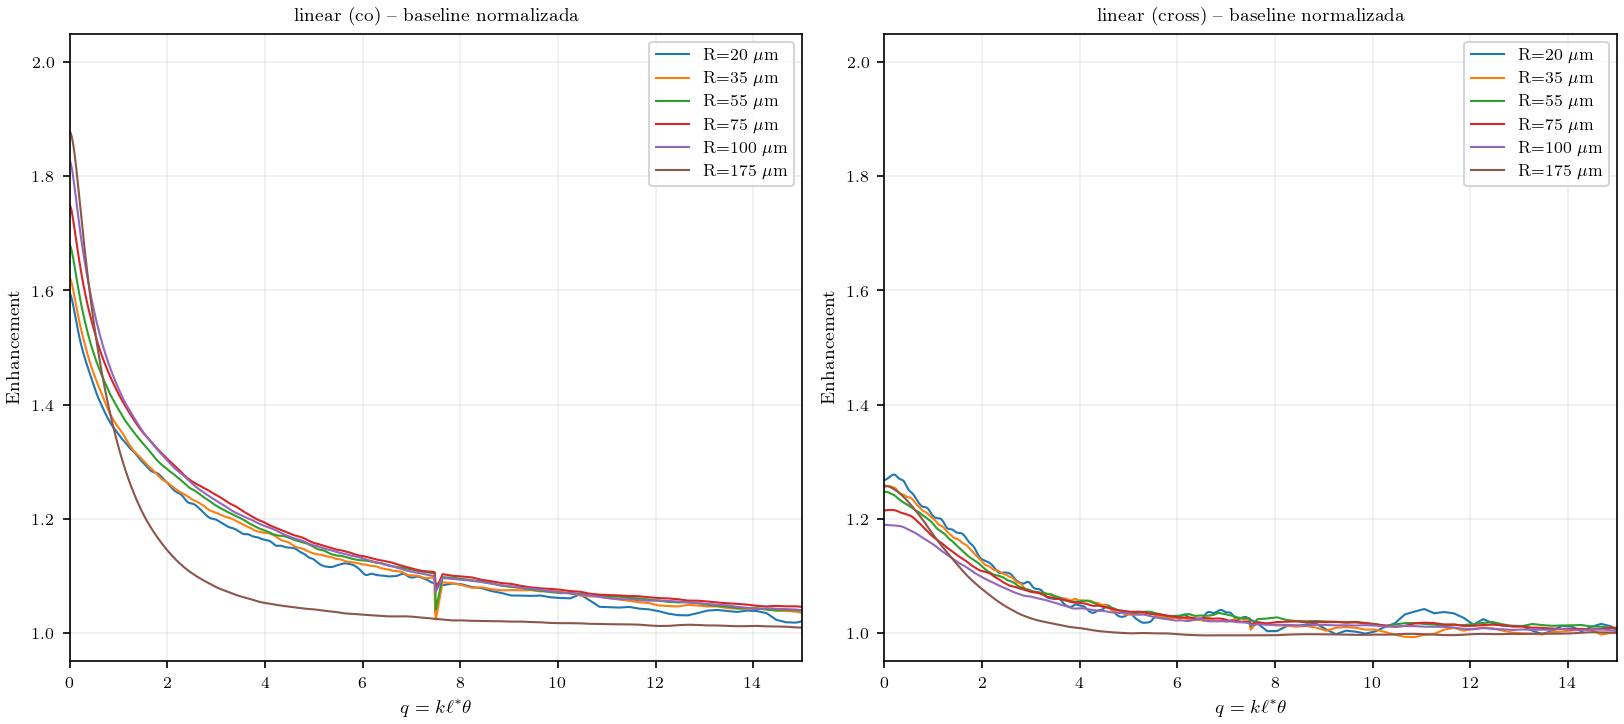

In [10]:
# ===========================================================================
# Observables §5.1 / §5.2 -- barrido homogeneo de radios (haz 2500 um, doble ventana)
#
# Sobre el perfil ya unido (det_1 fino + det_2 cola) y con baseline medida en
# la cola, extrae por radio y canal:
#   E(0)              factor de realce (tip promediado)
#   theta_FWHM        ancho del cono [mrad]
#   q_FWHM            ancho en unidades reducidas (= k l* theta_FWHM)
#   rho = 2 - E(0)    dilucion (solo lineal-co)
#   baseline_tail     nivel de fondo medido (chequeo: debe ~1 tras normalizar)
#
# Promedia replicas ANTES de extraer; usa la dispersion entre replicas como
# sigma (el scatter bin-a-bin miente con el estimador next-event).
# ===========================================================================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ===========================================================================
# Config
# ===========================================================================
SAVE_PATH = "/Users/niaggar/Results"
FOLDER = "study_rgd_particles__PLIN__beam2500"

RADIUS_VALUES = [0.020, 0.035, 0.055, 0.075, 0.100, 0.175]
N_REPLICAS = 5                      # sube a 4 en produccion

N_MEDIUM = 1.33
WAVELENGTH = 0.514
K_MEDIUM = 2.0 * np.pi * N_MEDIUM / WAVELENGTH   # 1/um

N_TIP = 8                           # bins promediados para E(0)
Q_BASELINE = 25.0                   # q por encima del cual se mide el fondo
REBIN = 4                           # solo para localizar el cruce FWHM (no E0)

# R=175 fuera de RGD y muy anisotropo -> promedio azimutal; resto phi_cut(0)
REDUCE_FOR = lambda rad: azimuthal_average if rad >= 0.175 else phi_cut(0)


# ===========================================================================
# Helpers
# ===========================================================================
def get_params(run):
    for attr in ("params_flat", "params"):
        p = getattr(run, attr, None)
        if p is not None:
            return p() if callable(p) else p
    raise AttributeError("ajusta get_params()")


def run_name(index, rad, rep):
    val = index * N_REPLICAS + rep
    return f"{val:04d}_radius_{rad:.3f}__rep{rep}"


def load_stitched(sweep, key, reduce, channel, lstar):
    """Une det_1 (fino) + det_2 (cola) con chequeo de solape.
    Devuelve theta[rad], g[canal]. NO normaliza baseline (eso va aparte)."""
    p1 = cbs_profiles(sweep[key].processed_cbs("farfield_cbs_1"),
                      basis=linear, time_index=0, reduce=reduce)
    p2 = cbs_profiles(sweep[key].processed_cbs("farfield_cbs_2"),
                      basis=linear, time_index=0, reduce=reduce)
    th1, g1 = np.asarray(p1.theta), np.asarray(p1.enhancement[channel])
    th2, g2 = np.asarray(p2.theta), np.asarray(p2.enhancement[channel])

    theta_1 = th1[-1]
    lo = 0.9 * theta_1
    ov = (th2 >= lo) & (th2 <= theta_1)
    if ov.any():
        g1_on2 = np.interp(th2[ov], th1, g1)
        resid = np.max(np.abs(g2[ov] - g1_on2))
        if resid > 0.05:
            print(f"[stitch WARN] {key} ch={channel}: solape max {resid:.3f} "
                  f"-> revisar normalizacion de angulo solido en det_1/det_2")

    keep2 = th2 > theta_1
    theta = np.concatenate([th1, th2[keep2]])
    g = np.concatenate([g1, g2[keep2]])
    order = np.argsort(theta)          # por si acaso
    return theta[order], g[order]


def average_replicas(sweep, index, rad, reduce, channel, lstar):
    """Promedia el perfil sobre replicas (interpoladas a la grilla theta de rep0).
    Devuelve theta, g_mean, g_std (std entre replicas; nan si N_REPLICAS==1)."""
    th_ref, g0 = load_stitched(sweep, run_name(index, rad, 0), reduce, channel, lstar)
    if N_REPLICAS == 1:
        return th_ref, g0, np.full_like(g0, np.nan)
    stack = [g0]
    for rep in range(1, N_REPLICAS):
        th_r, g_r = load_stitched(sweep, run_name(index, rad, rep), reduce, channel, lstar)
        stack.append(np.interp(th_ref, th_r, g_r))
    G = np.vstack(stack)
    return th_ref, G.mean(axis=0), G.std(axis=0, ddof=1)


def normalize_baseline(theta, g, lstar):
    """Resta el fondo medido en la cola (q > Q_BASELINE) y re-centra en 1."""
    q = K_MEDIUM * lstar * theta
    tail = q > Q_BASELINE
    base = np.median(g[tail]) if tail.any() else np.median(g[-50:])
    return g - base + 1.0, float(base)


def rebin(x, y, f):
    n = (len(x) // f) * f
    return x[:n].reshape(-1, f).mean(1), y[:n].reshape(-1, f).mean(1)


def extract(theta, g, lstar):
    """E(0), theta_FWHM[rad], q_FWHM sobre perfil ya normalizado a baseline 1."""
    E0 = float(np.mean(g[:N_TIP]))
    half = 1.0 + 0.5 * (E0 - 1.0)
    th_r, g_r = rebin(theta, g, REBIN)
    start = max(1, N_TIP // REBIN)
    below = np.where(g_r[start:] < half)[0]
    if len(below) == 0:
        return E0, np.nan, np.nan
    i = int(below[0]) + start
    th_half = float(np.interp(half, [g_r[i], g_r[i-1]], [th_r[i], th_r[i-1]]))
    fwhm = 2.0 * th_half
    return E0, fwhm, K_MEDIUM * lstar * fwhm


# ===========================================================================
# Carga + extraccion
# ===========================================================================
sweep = load_sweep(FOLDER, base_path=Path(SAVE_PATH))
print(f"claves: {list(sweep.keys())}\n")

rows = []
profiles_norm = {}   # (rad, channel) -> (theta, g_norm) para las figuras
for index, rad in enumerate(RADIUS_VALUES):
    p0 = get_params(sweep[run_name(index, rad, 0)])
    lstar = float(p0["transport_mean_free_path"])
    reduce = REDUCE_FOR(rad)

    rec = {"rad": rad, "lstar": lstar}
    for ch in ("co", "cross"):
        theta, g_mean, g_std = average_replicas(sweep, index, rad, reduce, ch, lstar)
        g_norm, base = normalize_baseline(theta, g_mean, lstar)
        E0, fwhm, qfwhm = extract(theta, g_norm, lstar)
        rec[f"E0_{ch}"] = E0
        rec[f"fwhm_{ch}_mrad"] = fwhm * 1e3
        rec[f"qfwhm_{ch}"] = qfwhm
        rec[f"base_{ch}"] = base
        profiles_norm[(rad, ch)] = (theta, g_norm)
    rec["rho_co"] = 2.0 - rec["E0_co"]
    rows.append(rec)

# ===========================================================================
# Tabla
# ===========================================================================
hdr = ("r[um]", "l*[um]", "E0_co", "rho_co", "FWHM_co[mrad]", "q_FWHM_co",
       "E0_cross", "FWHM_cr[mrad]", "base_co")
print("  ".join(f"{h:>13s}" for h in hdr))
for r in rows:
    print("  ".join(f"{v:>13.4f}" for v in (
        r["rad"], r["lstar"], r["E0_co"], r["rho_co"], r["fwhm_co_mrad"],
        r["qfwhm_co"], r["E0_cross"], r["fwhm_cross_mrad"], r["base_co"])))

# consistencia clave de §5.1: q_FWHM_co ~ constante entre radios (universalidad)
q_all = np.array([r["qfwhm_co"] for r in rows])
print(f"\nq_FWHM_co: media={np.nanmean(q_all):.3f}  std={np.nanstd(q_all):.3f}  "
      f"CV={100*np.nanstd(q_all)/np.nanmean(q_all):.1f}%  "
      f"(constante -> universalidad de la lineshape; outliers = R=20 haz, R=175 RGD)")

# ===========================================================================
# Figura: perfiles normalizados en q (colapso) -- canal co
# ===========================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
for index, rad in enumerate(RADIUS_VALUES):
    lstar = rows[index]["lstar"]
    for ax, ch in [(ax1, "co"), (ax2, "cross")]:
        theta, g = profiles_norm[(rad, ch)]
        q = K_MEDIUM * lstar * theta
        ax.plot(q, g, lw=1.0, label=rf"R={rad*1e3:.0f} $\mu$m")
for ax, t in [(ax1, "co"), (ax2, "cross")]:
    ax.set_xlabel(r"$q = k\ell^*\theta$")
    ax.set_ylabel("Enhancement")
    ax.set_xlim(0, 15)
    ax.set_ylim(0.95, 2.05)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
    ax.set_title(f"linear ({t}) -- baseline normalizada")
fig.tight_layout()
plt.show()

claves: ['0012_radius_0.055__rep2', '0021_radius_0.100__rep1', '0001_radius_0.020__rep1', '0016_radius_0.075__rep1', '0025_radius_0.175__rep0', '0007_radius_0.035__rep2', '0009_radius_0.035__rep4', '0015_radius_0.075__rep0', '0026_radius_0.175__rep1', '0023_radius_0.100__rep3', '0010_radius_0.055__rep0', '0005_radius_0.035__rep0', '0027_radius_0.175__rep2', '0019_radius_0.075__rep4', '0003_radius_0.020__rep3', '0014_radius_0.055__rep4', '0029_radius_0.175__rep4', '0017_radius_0.075__rep2', '0006_radius_0.035__rep1', '0028_radius_0.175__rep3', '0002_radius_0.020__rep2', '0011_radius_0.055__rep1', '0022_radius_0.100__rep2', '0018_radius_0.075__rep3', '0004_radius_0.020__rep4', '0024_radius_0.100__rep4', '0008_radius_0.035__rep3', '0000_radius_0.020__rep0', '0020_radius_0.100__rep0', '0013_radius_0.055__rep3']

C_AWM calibrada en R=0.075 um: C = 2.6331 (referencia teorica difusiva ~0.73)

     r[um]        w/l*         RGD      l*_teo      l*_med        err%       E0_co      rho_co   q_FW

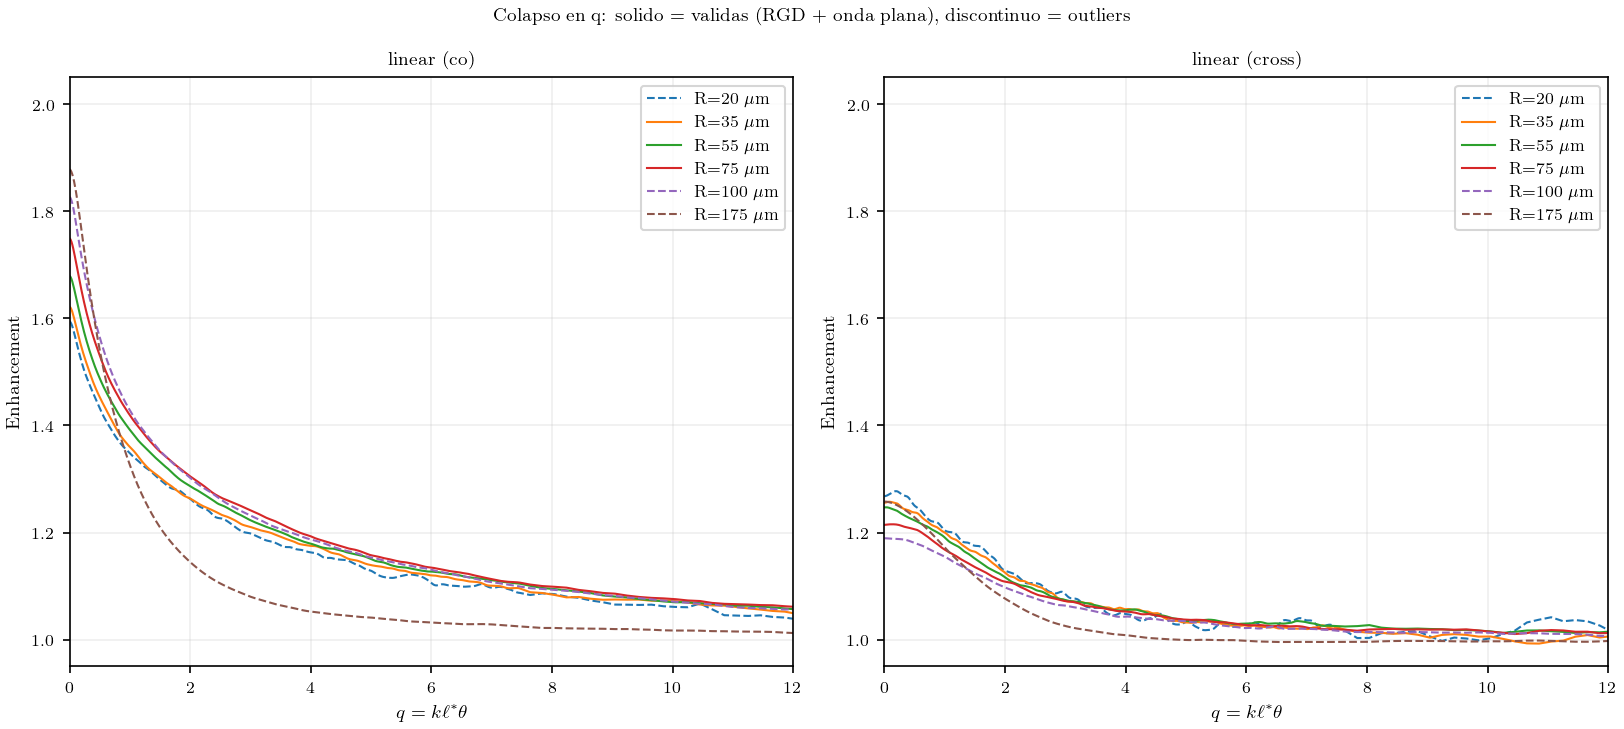

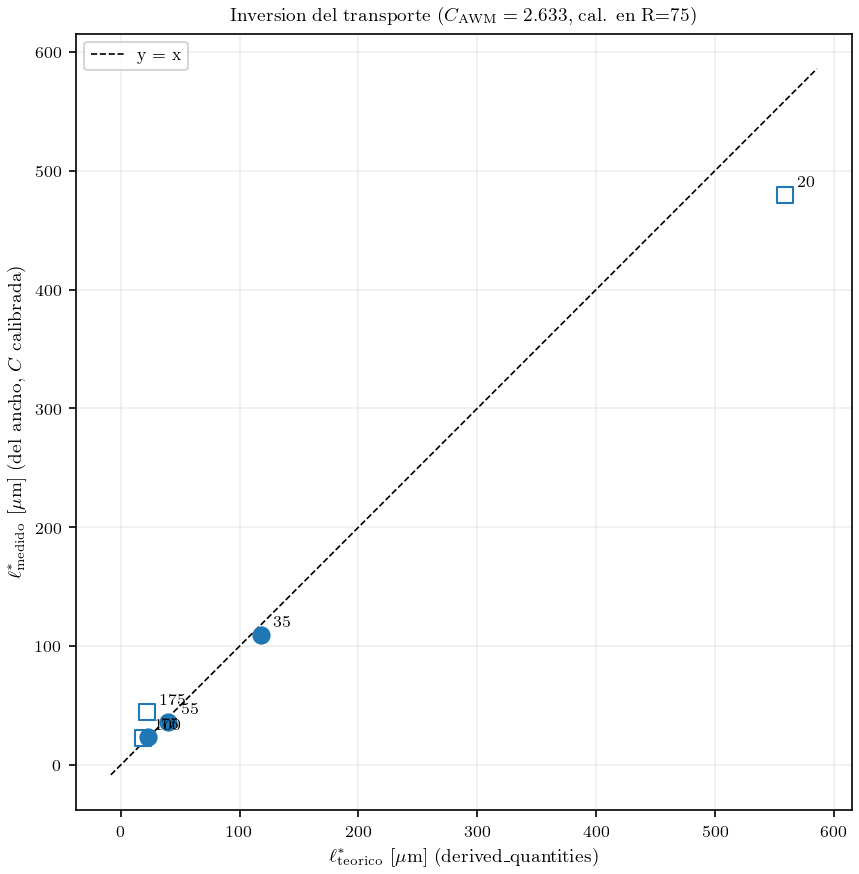

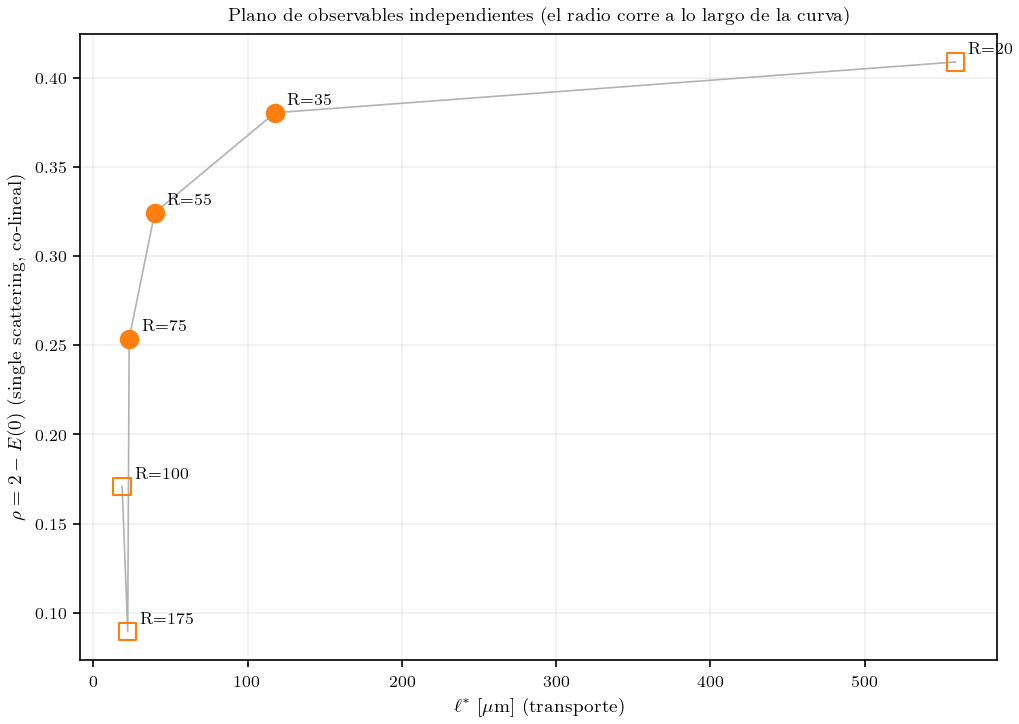

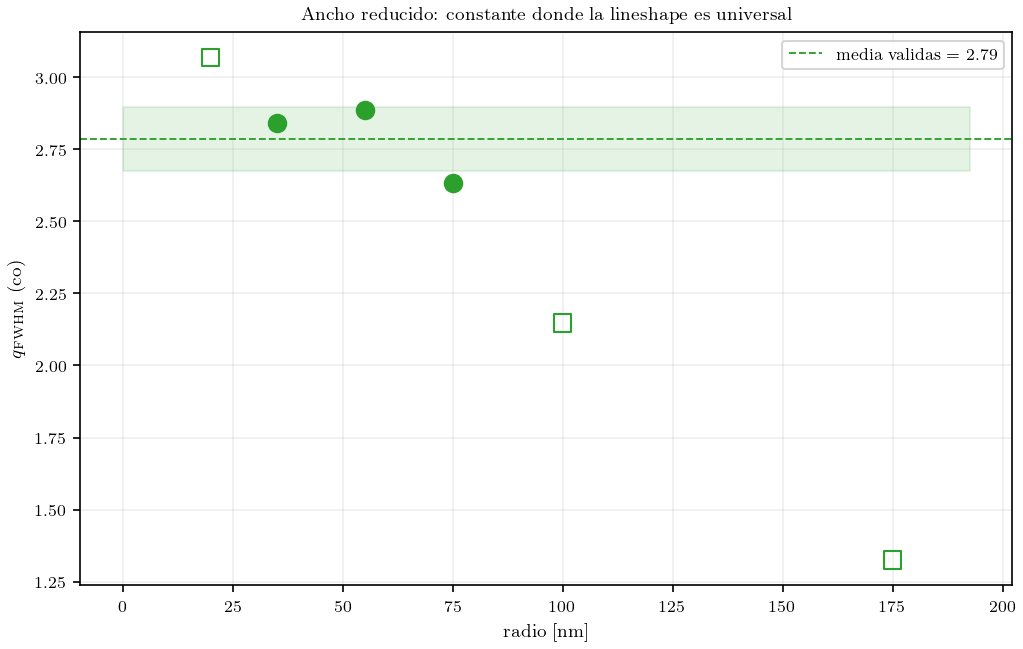

In [11]:
# ===========================================================================
# Observables fisicos del CBS -- barrido homogeneo de radios (§5.1 / §5.2)
#
# Pipeline:
#   1. Stitch det_1 (fino) + det_2 (cola), descarta bin de costura, chequea solape
#   2. Promedia replicas -> perfil + sigma entre replicas
#   3. Normaliza baseline en la cola (q > Q_BASELINE)
#   4. Extrae E(0) (fit parabolico del tip) y theta_FWHM (cruce media altura)
#   5. INVIERTE l*_medido del ancho, con constante C calibrada a una particula
#      de referencia dentro de validez -> observable fisico, no lectura teorica
#
# Figuras:
#   FIG1  colapso en q (co, cross)          -> universalidad de la lineshape
#   FIG2  l*_medido vs l*_teorico (y=x)      -> fidelidad del observable primario
#   FIG3  plano (l*, rho)                    -> dos observables independientes
#   FIG4  q_FWHM vs radio                    -> constante entre validas
#
# Un observable del CBS = transporte (l* del ancho) + funcion de fase en
# retrodispersion (rho de la altura). El CBS NO mide el radio directamente;
# el radio se recupera solo si se conoce n (densidad) o combinando observables.
# ===========================================================================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ===========================================================================
# Config
# ===========================================================================
SAVE_PATH = "/Users/niaggar/Results"
FOLDER = "study_rgd_particles__PLIN__beam2500"

RADIUS_VALUES = [0.020, 0.035, 0.055, 0.075, 0.100, 0.175]
N_REPLICAS = 5                       # sube a 4 en produccion

N_MEDIUM = 1.33
WAVELENGTH = 0.514
K_MEDIUM = 2.0 * np.pi * N_MEDIUM / WAVELENGTH    # 1/um

# --- Validez fisica por radio (para clasificar outliers, NO para excluir) ---
#   dentro_RGD:  condicion 2 (x*|m-1|) < ~0.3   -> RGD estricto
#   onda_plana:  w/l* > ~10                     -> tip no redondeado por haz
LASER_RADIUS_UM = 2500.0
RGD_VALID = {0.020: True, 0.035: True, 0.055: True, 0.075: True, 0.175: False}

# Particula de referencia para calibrar C_AWM: dentro de RGD y en onda plana.
# R=75 (o 55): validez RGD y w/l* ~ 100. Se define C tal que l*_medido == l*_teo
# para esta, y se PREDICE el resto con esa misma C.
R_CALIB = 0.075

# --- Extraccion ---
N_TIP_FALLBACK = 8
Q_FIT_TIP = 1.5                      # ajuste parabolico del tip en q < 1.5
Q_BASELINE = 25.0                    # fondo medido por encima de este q
REBIN = 4                            # solo para localizar el cruce FWHM

REDUCE_FOR = lambda rad: azimuthal_average if rad >= 0.175 else phi_cut(0)

SHOW = {"table": True, "fig_collapse": True, "fig_lstar": True,
        "fig_plane": True, "fig_qfwhm": True}


# ===========================================================================
# Carga y stitching
# ===========================================================================
def get_params(run):
    for attr in ("params_flat", "params"):
        p = getattr(run, attr, None)
        if p is not None:
            return p() if callable(p) else p
    raise AttributeError("ajusta get_params()")


def find_run(sweep, rad, rep):
    """Resuelve el run por sufijo (robusto al prefijo del SweepManager)."""
    suffix = f"radius_{rad:.3f}__rep{rep}"
    matches = [k for k in sweep.keys() if k.endswith(suffix)]
    if len(matches) != 1:
        raise KeyError(f"'{suffix}': {matches}")
    return sweep[matches[0]]


def load_stitched(run, reduce, channel):
    """Une det_1 + det_2, promedia el solape, descarta el bin de costura.
    Devuelve theta[rad], g[canal]. Sin normalizar baseline."""
    p1 = cbs_profiles(run.processed_cbs("farfield_cbs_1"),
                      basis=linear, time_index=0, reduce=reduce)
    p2 = cbs_profiles(run.processed_cbs("farfield_cbs_2"),
                      basis=linear, time_index=0, reduce=reduce)
    th1, g1 = np.asarray(p1.theta), np.asarray(p1.enhancement[channel])
    th2, g2 = np.asarray(p2.theta), np.asarray(p2.enhancement[channel])

    theta_1 = th1[-1]
    lo = 0.9 * theta_1

    # chequeo de solape: det_1 interpolado sobre los bins de solape de det_2
    ov = (th2 >= lo) & (th2 <= theta_1)
    stitch_resid = np.nan
    if ov.any():
        g1_on2 = np.interp(th2[ov], th1, g1)
        stitch_resid = float(np.max(np.abs(g2[ov] - g1_on2)))
        if stitch_resid > 0.05:
            print(f"[stitch WARN] ch={channel}: solape max {stitch_resid:.3f} "
                  f"-> revisar normalizacion de angulo solido en postprocess")

    # une det_1 + det_2 estrictamente por encima de theta_1
    keep2 = th2 > theta_1
    theta = np.concatenate([th1, th2[keep2]])
    g = np.concatenate([g1, g2[keep2]])

    # descarta el bin fronterizo (costura): un bin a cada lado de theta_1
    d = np.abs(theta - theta_1)
    bad = np.argsort(d)[:2]
    mask = np.ones(len(theta), bool); mask[bad] = False
    theta, g = theta[mask], g[mask]

    order = np.argsort(theta)
    return theta[order], g[order], stitch_resid


def average_replicas(sweep, rad, reduce, channel):
    """Promedia sobre replicas (interpoladas a la grilla de rep0).
    Devuelve theta, g_mean, g_std."""
    th_ref, g0, _ = load_stitched(find_run(sweep, rad, 0), reduce, channel)
    if N_REPLICAS == 1:
        return th_ref, g0, np.full_like(g0, np.nan)
    stack = [g0]
    for rep in range(1, N_REPLICAS):
        th_r, g_r, _ = load_stitched(find_run(sweep, rad, rep), reduce, channel)
        stack.append(np.interp(th_ref, th_r, g_r))
    G = np.vstack(stack)
    return th_ref, G.mean(0), G.std(0, ddof=1)


def normalize_baseline(theta, g, lstar):
    """Resta el fondo medido en la cola (q > Q_BASELINE), re-centra en 1."""
    q = K_MEDIUM * lstar * theta
    tail = q > Q_BASELINE
    base = float(np.median(g[tail])) if tail.any() else float(np.median(g[-50:]))
    return g - base + 1.0, base


# ===========================================================================
# Extraccion de observables
# ===========================================================================
def rebin(x, y, f):
    n = (len(x) // f) * f
    return x[:n].reshape(-1, f).mean(1), y[:n].reshape(-1, f).mean(1)


def extract(theta, g, lstar):
    """E(0) por ajuste parabolico del tip (robusto al ruido de pocos hits);
    theta_FWHM[rad] por cruce a media altura sobre el perfil re-binneado.
    g debe venir YA normalizado a baseline 1."""
    q = K_MEDIUM * lstar * theta

    # --- E(0): g ~ E0 + a q^2 en q < Q_FIT_TIP (parabola simetrica, g'(0)=0) ---
    m = q < Q_FIT_TIP
    if m.sum() >= 6:
        c = np.polyfit(q[m], g[m], 2)     # c = [a, b, E0]; b ~ 0 por simetria
        E0 = float(c[2])
    else:
        E0 = float(np.mean(g[:N_TIP_FALLBACK]))

    # --- theta_FWHM: primer cruce por debajo de media altura ---
    half = 1.0 + 0.5 * (E0 - 1.0)
    th_r, g_r = rebin(theta, g, REBIN)
    below = np.where(g_r[1:] < half)[0]
    if len(below) == 0:
        return E0, np.nan, np.nan
    i = int(below[0]) + 1
    th_half = float(np.interp(half, [g_r[i], g_r[i-1]], [th_r[i], th_r[i-1]]))
    fwhm = 2.0 * th_half
    return E0, fwhm, K_MEDIUM * lstar * fwhm


# ===========================================================================
# Carga + extraccion de todos los radios
# ===========================================================================
sweep = load_sweep(FOLDER, base_path=Path(SAVE_PATH))
print(f"claves: {list(sweep.keys())}\n")

rows = []
prof_norm = {}                        # (rad, ch) -> (theta, g_norm)
for rad in RADIUS_VALUES:
    p0 = get_params(find_run(sweep, rad, 0))
    lstar_theo = float(p0["transport_mean_free_path"])
    reduce = REDUCE_FOR(rad)

    rec = {"rad": rad, "lstar_theo": lstar_theo,
           "w_over_lstar": LASER_RADIUS_UM / lstar_theo,
           "rgd": RGD_VALID.get(rad, False)}
    for ch in ("co", "cross"):
        theta, g_mean, g_std = average_replicas(sweep, rad, reduce, ch)
        g_norm, base = normalize_baseline(theta, g_mean, lstar_theo)
        E0, fwhm, qfwhm = extract(theta, g_norm, lstar_theo)
        rec[f"E0_{ch}"] = E0
        rec[f"fwhm_{ch}"] = fwhm            # rad
        rec[f"qfwhm_{ch}"] = qfwhm
        rec[f"base_{ch}"] = base
        prof_norm[(rad, ch)] = (theta, g_norm)
    rec["rho_co"] = 2.0 - rec["E0_co"]
    rows.append(rec)

# --- Calibracion de C_AWM con la particula de referencia ---
#   theta_FWHM = C / (k l*)  ->  C = theta_FWHM_ref * k * l*_theo_ref
ref = next(r for r in rows if np.isclose(r["rad"], R_CALIB))
C_AWM = ref["fwhm_co"] * K_MEDIUM * ref["lstar_theo"]
print(f"C_AWM calibrada en R={R_CALIB} um: C = {C_AWM:.4f} "
      f"(referencia teorica difusiva ~0.73)\n")

# --- Inversion: l*_medido del ancho, con C calibrada ---
for r in rows:
    r["lstar_meas"] = C_AWM / (K_MEDIUM * r["fwhm_co"]) if np.isfinite(r["fwhm_co"]) else np.nan
    r["lstar_err_pct"] = 100.0 * (r["lstar_meas"] - r["lstar_theo"]) / r["lstar_theo"]


# ===========================================================================
# Tabla
# ===========================================================================
if SHOW["table"]:
    hdr = ("r[um]", "w/l*", "RGD", "l*_teo", "l*_med", "err%", "E0_co",
           "rho_co", "q_FWHM_co", "E0_cross")
    print("  ".join(f"{h:>10s}" for h in hdr))
    for r in rows:
        print(f"{r['rad']:>10.3f}  {r['w_over_lstar']:>10.1f}  "
              f"{str(r['rgd']):>10s}  {r['lstar_theo']:>10.2f}  "
              f"{r['lstar_meas']:>10.2f}  {r['lstar_err_pct']:>+10.1f}  "
              f"{r['E0_co']:>10.4f}  {r['rho_co']:>10.4f}  "
              f"{r['qfwhm_co']:>10.3f}  {r['E0_cross']:>10.4f}")

    # universalidad: q_FWHM constante ENTRE LAS VALIDAS (RGD + onda plana)
    valid = [r for r in rows if r["rgd"] and r["w_over_lstar"] > 10]
    q_valid = np.array([r["qfwhm_co"] for r in valid])
    r_valid = [f"{r['rad']}" for r in valid]
    print(f"\nq_FWHM_co (validas {r_valid}): media={q_valid.mean():.3f} "
          f"std={q_valid.std():.3f} CV={100*q_valid.std()/q_valid.mean():.1f}%")
    print("  (constante -> lineshape universal en q; R=20 haz finito, "
          "R=175 fuera de RGD son outliers con causa conocida)")


# ===========================================================================
# FIG1 -- Colapso en q (co, cross)
# ===========================================================================
if SHOW["fig_collapse"]:
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 5))
    for r in rows:
        rad, lstar = r["rad"], r["lstar_theo"]
        style = "--" if not (r["rgd"] and r["w_over_lstar"] > 10) else "-"
        for ax, ch in [(a1, "co"), (a2, "cross")]:
            th, g = prof_norm[(rad, ch)]
            q = K_MEDIUM * lstar * th
            ax.plot(q, g, style, lw=1.0, label=rf"R={rad*1e3:.0f} $\mu$m")
    for ax, t in [(a1, "co"), (a2, "cross")]:
        ax.set_xlabel(r"$q = k\ell^*\theta$"); ax.set_ylabel("Enhancement")
        ax.set_xlim(0, 12); ax.set_ylim(0.95, 2.05); ax.grid(alpha=0.2)
        ax.legend(fontsize=8); ax.set_title(f"linear ({t})")
    fig.suptitle("Colapso en q: solido = validas (RGD + onda plana), "
                 "discontinuo = outliers", fontsize=9)
    fig.tight_layout(); plt.show()


# ===========================================================================
# FIG2 -- l*_medido vs l*_teorico (fidelidad del observable primario)
# ===========================================================================
if SHOW["fig_lstar"]:
    fig, ax = plt.subplots(figsize=(6, 6))
    lo = min(min(r["lstar_theo"] for r in rows), min(r["lstar_meas"] for r in rows))
    hi = max(max(r["lstar_theo"] for r in rows), max(r["lstar_meas"] for r in rows))
    pad = 0.05 * (hi - lo)
    ax.plot([lo-pad, hi+pad], [lo-pad, hi+pad], "k--", lw=0.8, label="y = x")
    for r in rows:
        ok = r["rgd"] and r["w_over_lstar"] > 10
        ax.scatter(r["lstar_theo"], r["lstar_meas"],
                   s=60, marker="o" if ok else "s",
                   facecolor="C0" if ok else "none", edgecolor="C0",
                   zorder=3)
        ax.annotate(rf"{r['rad']*1e3:.0f}",
                    (r["lstar_theo"], r["lstar_meas"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=8)
    ax.set_xlabel(r"$\ell^*_{\rm teorico}$ [$\mu$m]  (derived\_quantities)")
    ax.set_ylabel(r"$\ell^*_{\rm medido}$ [$\mu$m]  (del ancho, $C$ calibrada)")
    ax.set_title(rf"Inversion del transporte  ($C_{{\rm AWM}}={C_AWM:.3f}$, "
                 rf"cal. en R={R_CALIB*1e3:.0f})")
    ax.legend(); ax.grid(alpha=0.2); ax.set_aspect("equal")
    fig.tight_layout(); plt.show()


# ===========================================================================
# FIG3 -- Plano (l*, rho): dos observables independientes
# ===========================================================================
if SHOW["fig_plane"]:
    fig, ax = plt.subplots(figsize=(7, 5))
    ls = np.array([r["lstar_theo"] for r in rows])
    rho = np.array([r["rho_co"] for r in rows])
    order = np.argsort(ls)
    ax.plot(ls[order], rho[order], "-", color="gray", lw=0.8, alpha=0.6, zorder=1)
    for r in rows:
        ok = r["rgd"] and r["w_over_lstar"] > 10
        ax.scatter(r["lstar_theo"], r["rho_co"], s=70,
                   marker="o" if ok else "s",
                   facecolor="C1" if ok else "none", edgecolor="C1", zorder=3)
        ax.annotate(rf"R={r['rad']*1e3:.0f}",
                    (r["lstar_theo"], r["rho_co"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=8)
    ax.set_xlabel(r"$\ell^*$ [$\mu$m]  (transporte)")
    ax.set_ylabel(r"$\rho = 2 - E(0)$  (single scattering, co-lineal)")
    ax.set_title("Plano de observables independientes  "
                 "(el radio corre a lo largo de la curva)")
    ax.grid(alpha=0.2)
    fig.tight_layout(); plt.show()


# ===========================================================================
# FIG4 -- q_FWHM vs radio (constante entre validas)
# ===========================================================================
if SHOW["fig_qfwhm"]:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for r in rows:
        ok = r["rgd"] and r["w_over_lstar"] > 10
        ax.scatter(r["rad"]*1e3, r["qfwhm_co"], s=70,
                   marker="o" if ok else "s",
                   facecolor="C2" if ok else "none", edgecolor="C2", zorder=3)
    valid = [r for r in rows if r["rgd"] and r["w_over_lstar"] > 10]
    q_valid = np.array([r["qfwhm_co"] for r in valid])
    ax.axhline(q_valid.mean(), color="C2", ls="--", lw=0.9,
               label=rf"media validas = {q_valid.mean():.2f}")
    ax.fill_between([0, RADIUS_VALUES[-1]*1e3*1.1],
                    q_valid.mean()-q_valid.std(), q_valid.mean()+q_valid.std(),
                    color="C2", alpha=0.12)
    ax.set_xlabel(r"radio [nm]"); ax.set_ylabel(r"$q_{\rm FWHM}$ (co)")
    ax.set_title("Ancho reducido: constante donde la lineshape es universal")
    ax.legend(); ax.grid(alpha=0.2)
    fig.tight_layout(); plt.show()